# Sales Performance Analysis — Superstore Retail Dataset

**Author:** Data Analyst Portfolio Project
**Dataset:** Synthetic Superstore-style retail transactions (5,500+ line items, 2021–2024)
**Objective:** Diagnose where revenue and profit are being made and lost across time,
region, product, and discounting behavior — and quantify exactly how much profit
is being destroyed by over-discounting.

This notebook covers:
1. Data overview & sanity checks
2. Revenue & profit trends over time
3. Product performance (best sellers vs. least profitable)
4. Regional performance
5. Discount vs. Profit relationship — finding the breakeven threshold
6. Customer segment analysis
7. **Profit Leakage Analysis** (headline insight)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

PALETTE = {
    "primary": "#1F4E79",
    "accent":  "#E8743B",
    "positive": "#2E8B57",
    "negative": "#C0392B",
    "neutral": "#8C9BAB",
}
sns.set_palette([PALETTE["primary"], PALETTE["accent"], "#4C8577", "#B08968", "#7A5195"])

VISUALS_DIR = "../visuals"
import os
os.makedirs(VISUALS_DIR, exist_ok=True)

def savefig(fig, name, tight=True):
    if tight:
        fig.tight_layout()
    fig.savefig(f"{VISUALS_DIR}/{name}.png", dpi=200, bbox_inches="tight", facecolor="white")
    print(f"Saved visuals/{name}.png")


## 1. Data Overview

In [2]:
df = pd.read_csv("../data/cleaned/superstore_sales_cleaned.csv", parse_dates=["Order Date", "Ship Date"])
df["Order Month"] = pd.to_datetime(df["Order Month"])
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Date range: {df['Order Date'].min().date()}  to  {df['Order Date'].max().date()}")
df.head()


Rows: 5,556  |  Columns: 23
Date range: 2021-01-01  to  2024-12-31


,Row ID,Order ID,Order Date,Ship Date,Month-Year,Order Month,Year,Quarter,Customer Name,Segment,...,Product Name,Quantity,Unit Price,Discount,Discount Bucket,Sales,Profit,Profit Margin (%),Order Processing Time (Days),Is Loss Making
0,1,US-2021-100061,2021-01-01,2021-06-01,Jan-2021,2021-01-01,2021,2021Q1,Olivia Anderson,Consumer,...,Global Deluxe Chair Value,2,345.10,0.00,Low,690.20,221.68,32.12,151,False
1,2,US-2021-101581,2021-01-01,2021-06-01,Jan-2021,2021-01-01,2021,2021Q1,Liam Wright,Consumer,...,Xerox Multipurpose Paper Standard,5,5.17,0.40,High,25.87,9.71,37.53,151,False
2,3,US-2021-102115,2021-01-01,2021-05-01,Jan-2021,2021-01-01,2021,2021Q1,Olivia Rodriguez,Consumer,...,Canon imageCLASS Copier Standard,1,"1,472.94",0.00,Low,"1,472.94",291.49,19.79,120,False
3,4,US-2021-102114,2021-01-01,2021-01-06,Jan-2021,2021-01-01,2021,2021Q1,Amit Smith,Home Office,...,Apple iPhone Accessory Pro,1,89.78,0.50,High,89.78,-40.40,-45.00,5,True
4,5,US-2021-101581,2021-01-01,2021-01-06,Jan-2021,2021-01-01,2021,2021Q1,Liam Wright,Consumer,...,O'Sullivan Bookcase Standard,1,91.48,0.70,High,91.48,-114.10,-124.73,5,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5556 entries, 0 to 5555
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Row ID                        5556 non-null   int64         
 1   Order ID                      5556 non-null   str           
 2   Order Date                    5556 non-null   datetime64[us]
 3   Ship Date                     5556 non-null   datetime64[us]
 4   Month-Year                    5556 non-null   str           
 5   Order Month                   5556 non-null   datetime64[us]
 6   Year                          5556 non-null   int64         
 7   Quarter                       5556 non-null   str           
 8   Customer Name                 5556 non-null   str           
 9   Segment                       5556 non-null   str           
 10  Region                        5556 non-null   str           
 11  Category                      5556 non-nu

In [4]:
summary = pd.DataFrame({
    "Total Revenue": [df["Sales"].sum()],
    "Total Profit": [df["Profit"].sum()],
    "Overall Profit Margin %": [round(df["Profit"].sum() / df["Sales"].sum() * 100, 2)],
    "Total Orders": [df["Order ID"].nunique()],
    "Total Line Items": [len(df)],
    "Avg Order Value": [round(df.groupby("Order ID")["Sales"].sum().mean(), 2)],
})
summary.T.rename(columns={0: "Value"})


,Value
Total Revenue,"2,156,007.46"
Total Profit,"286,163.40"
Overall Profit Margin %,13.27
Total Orders,"3,315.00"
Total Line Items,"5,556.00"
Avg Order Value,650.38


## 2. Revenue & Profit Trends Over Time

Saved visuals/01_monthly_revenue_profit_trend.png


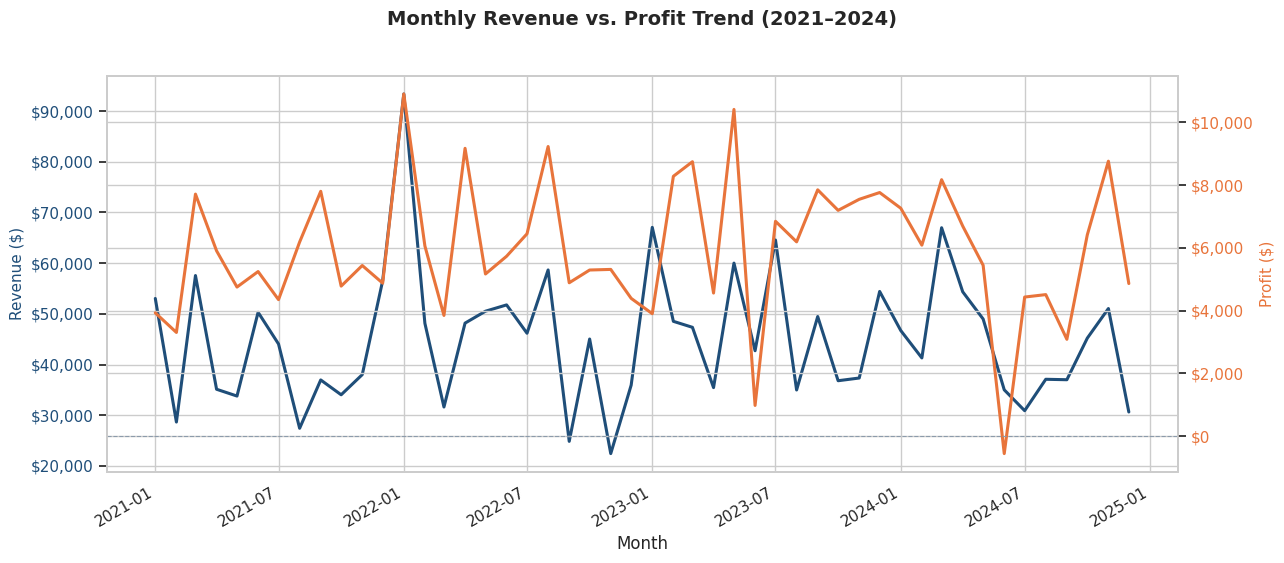

In [5]:
monthly = df.groupby("Order Month").agg(Revenue=("Sales","sum"), Profit=("Profit","sum")).reset_index()

fig, ax1 = plt.subplots(figsize=(13,5.5))
ax1.plot(monthly["Order Month"], monthly["Revenue"], color=PALETTE["primary"], linewidth=2.2, label="Revenue")
ax1.set_ylabel("Revenue ($)", color=PALETTE["primary"], fontsize=11)
ax1.tick_params(axis='y', labelcolor=PALETTE["primary"])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(monthly["Order Month"], monthly["Profit"], color=PALETTE["accent"], linewidth=2.2, label="Profit")
ax2.set_ylabel("Profit ($)", color=PALETTE["accent"], fontsize=11)
ax2.tick_params(axis='y', labelcolor=PALETTE["accent"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.axhline(0, color=PALETTE["neutral"], linewidth=0.8, linestyle="--")

fig.suptitle("Monthly Revenue vs. Profit Trend (2021–2024)", fontsize=14, fontweight="bold", y=1.02)
ax1.set_xlabel("Month")
fig.autofmt_xdate()
savefig(fig, "01_monthly_revenue_profit_trend")
plt.show()


Saved visuals/02_quarterly_revenue_profit.png


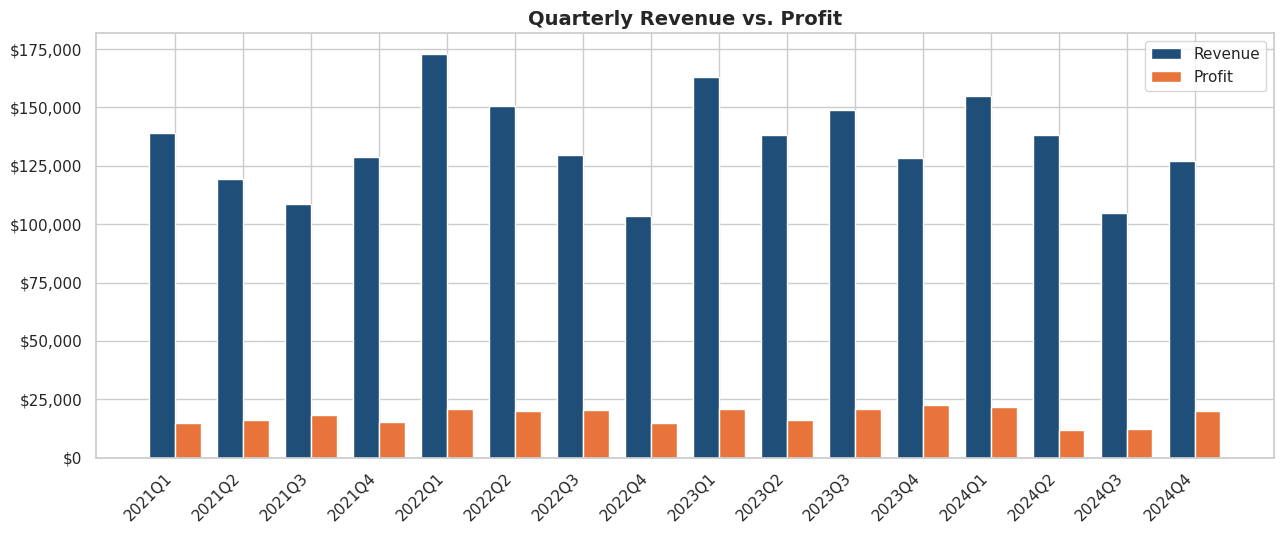

In [6]:
df["Quarter Label"] = df["Order Date"].dt.to_period("Q").astype(str)
quarterly = df.groupby("Quarter Label").agg(Revenue=("Sales","sum"), Profit=("Profit","sum")).reset_index()

fig, ax = plt.subplots(figsize=(13,5.5))
x = np.arange(len(quarterly))
width = 0.38
ax.bar(x - width/2, quarterly["Revenue"], width, label="Revenue", color=PALETTE["primary"])
ax.bar(x + width/2, quarterly["Profit"], width, label="Profit", color=PALETTE["accent"])
ax.set_xticks(x)
ax.set_xticklabels(quarterly["Quarter Label"], rotation=45, ha="right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.set_title("Quarterly Revenue vs. Profit", fontsize=14, fontweight="bold")
ax.legend()
savefig(fig, "02_quarterly_revenue_profit")
plt.show()


**Reading the trend:** Revenue and profit broadly move together, but profit growth
lags revenue growth in several quarters — a first hint that discounting or cost mix
is eating into margin even as top-line sales grow. We quantify this precisely in
Section 7 (Profit Leakage Analysis).

## 3. Product Performance — Best Sellers vs. Least Profitable

Saved visuals/03_top10_products_revenue.png


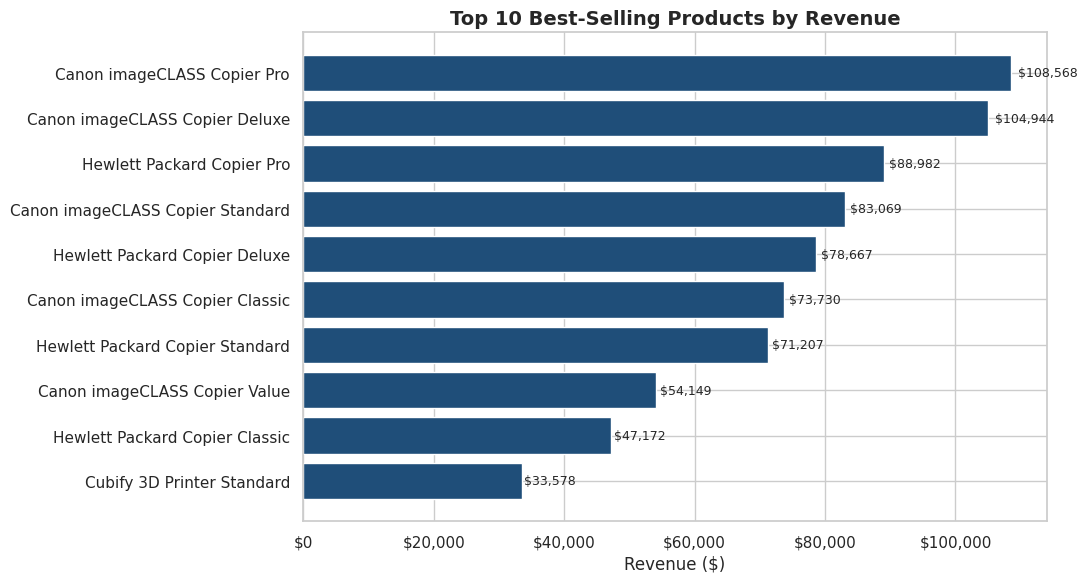

,Product Name,Revenue,Profit,Profit Margin %,Units
57,Canon imageCLASS Copier Pro,"108,567.65","7,507.32",6.90,92
56,Canon imageCLASS Copier Deluxe,"104,943.54","15,298.13",14.60,68
117,Hewlett Packard Copier Pro,"88,981.73","8,379.34",9.40,65
58,Canon imageCLASS Copier Standard,"83,069.18","5,197.21",6.30,71
116,Hewlett Packard Copier Deluxe,"78,666.97","1,347.98",1.70,64
55,Canon imageCLASS Copier Classic,"73,729.57",605.11,0.80,64
118,Hewlett Packard Copier Standard,"71,206.81","8,542.48",12.00,53
59,Canon imageCLASS Copier Value,"54,149.35","1,752.09",3.20,45
115,Hewlett Packard Copier Classic,"47,171.87","1,745.68",3.70,39
73,Cubify 3D Printer Standard,"33,578.02","3,658.92",10.90,47


In [7]:
product_perf = df.groupby("Product Name").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Units=("Quantity","sum"),
    Orders=("Order ID","nunique"),
).reset_index()
product_perf["Profit Margin %"] = round(product_perf["Profit"] / product_perf["Revenue"] * 100, 1)

top10_revenue = product_perf.sort_values("Revenue", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11,6))
bars = ax.barh(top10_revenue["Product Name"][::-1], top10_revenue["Revenue"][::-1], color=PALETTE["primary"])
ax.set_xlabel("Revenue ($)")
ax.set_title("Top 10 Best-Selling Products by Revenue", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
for b in bars:
    ax.text(b.get_width()*1.01, b.get_y()+b.get_height()/2, f"${b.get_width():,.0f}", va="center", fontsize=9)
savefig(fig, "03_top10_products_revenue")
plt.show()
top10_revenue[["Product Name","Revenue","Profit","Profit Margin %","Units"]]


Saved visuals/04_bottom10_products_profit.png


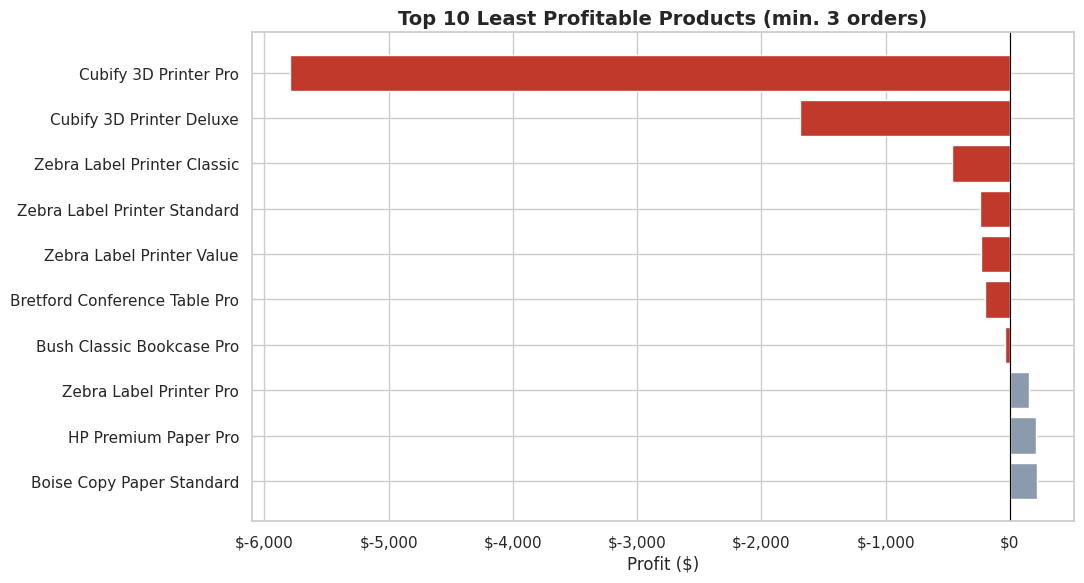

,Product Name,Revenue,Profit,Profit Margin %,Units
72,Cubify 3D Printer Pro,"22,815.15","-5,797.95",-25.40,46
71,Cubify 3D Printer Deluxe,"13,843.81","-1,688.90",-12.20,24
225,Zebra Label Printer Classic,"22,011.16",-468.40,-2.10,39
228,Zebra Label Printer Standard,"14,823.31",-238.66,-1.60,27
229,Zebra Label Printer Value,"23,581.04",-231.74,-1.00,40
47,Bretford Conference Table Pro,"12,523.54",-200.25,-1.60,50
52,Bush Classic Bookcase Pro,"7,174.05",-36.92,-0.50,38
227,Zebra Label Printer Pro,"23,328.33",151.73,0.70,40
107,HP Premium Paper Pro,352.58,210.59,59.70,31
38,Boise Copy Paper Standard,352.18,215.25,61.10,37


In [8]:
least_profitable = product_perf[product_perf["Orders"] >= 3].sort_values("Profit").head(10)

fig, ax = plt.subplots(figsize=(11,6))
colors = [PALETTE["negative"] if v < 0 else PALETTE["neutral"] for v in least_profitable["Profit"][::-1]]
bars = ax.barh(least_profitable["Product Name"][::-1], least_profitable["Profit"][::-1], color=colors)
ax.set_xlabel("Profit ($)")
ax.set_title("Top 10 Least Profitable Products (min. 3 orders)", fontsize=14, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
savefig(fig, "04_bottom10_products_profit")
plt.show()
least_profitable[["Product Name","Revenue","Profit","Profit Margin %","Units"]]


## 4. Regional Performance

Saved visuals/05_regional_performance.png


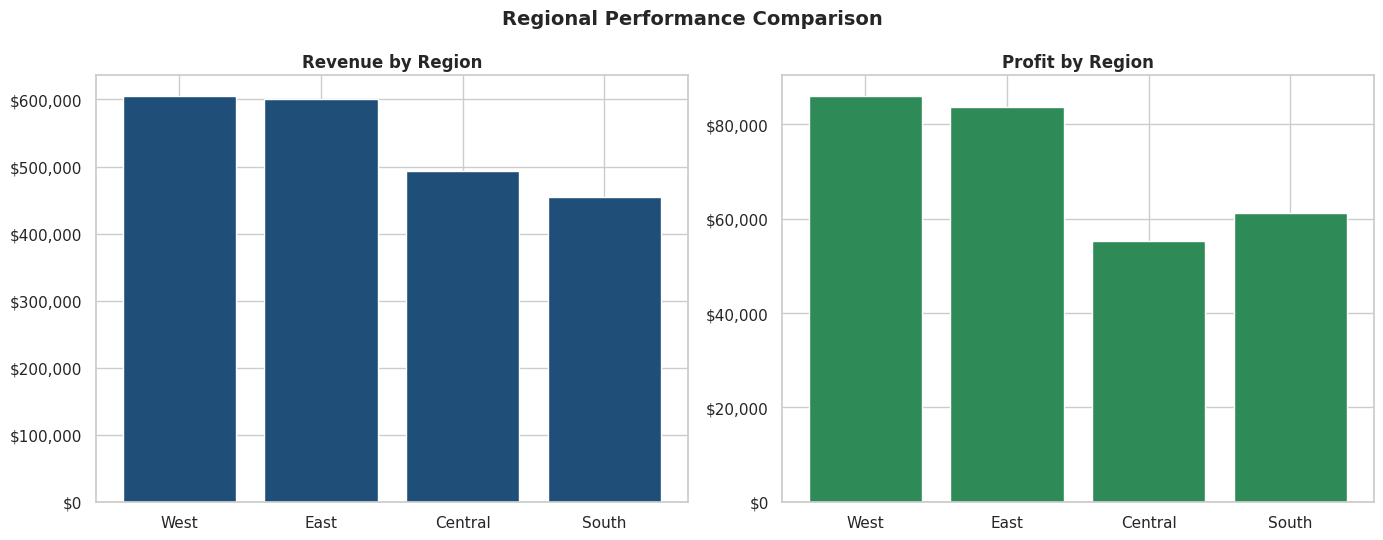

,Region,Revenue,Profit,Orders,Profit Margin %
3,West,"605,752.62","86,086.82",921,14.20
1,East,"601,077.80","83,686.40",998,13.90
0,Central,"493,987.22","55,224.22",799,11.20
2,South,"455,189.82","61,165.96",597,13.40


In [9]:
region_perf = df.groupby("Region").agg(
    Revenue=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order ID","nunique")
).reset_index()
region_perf["Profit Margin %"] = round(region_perf["Profit"] / region_perf["Revenue"] * 100, 1)
region_perf = region_perf.sort_values("Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))

axes[0].bar(region_perf["Region"], region_perf["Revenue"], color=PALETTE["primary"])
axes[0].set_title("Revenue by Region", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))

bar_colors = [PALETTE["positive"] if v >= 0 else PALETTE["negative"] for v in region_perf["Profit"]]
axes[1].bar(region_perf["Region"], region_perf["Profit"], color=bar_colors)
axes[1].set_title("Profit by Region", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[1].axhline(0, color="black", linewidth=0.8)

fig.suptitle("Regional Performance Comparison", fontsize=14, fontweight="bold")
savefig(fig, "05_regional_performance")
plt.show()
region_perf


## 5. Discount vs. Profit — Finding the Breakeven Threshold

Saved visuals/06_discount_vs_profit_scatter.png


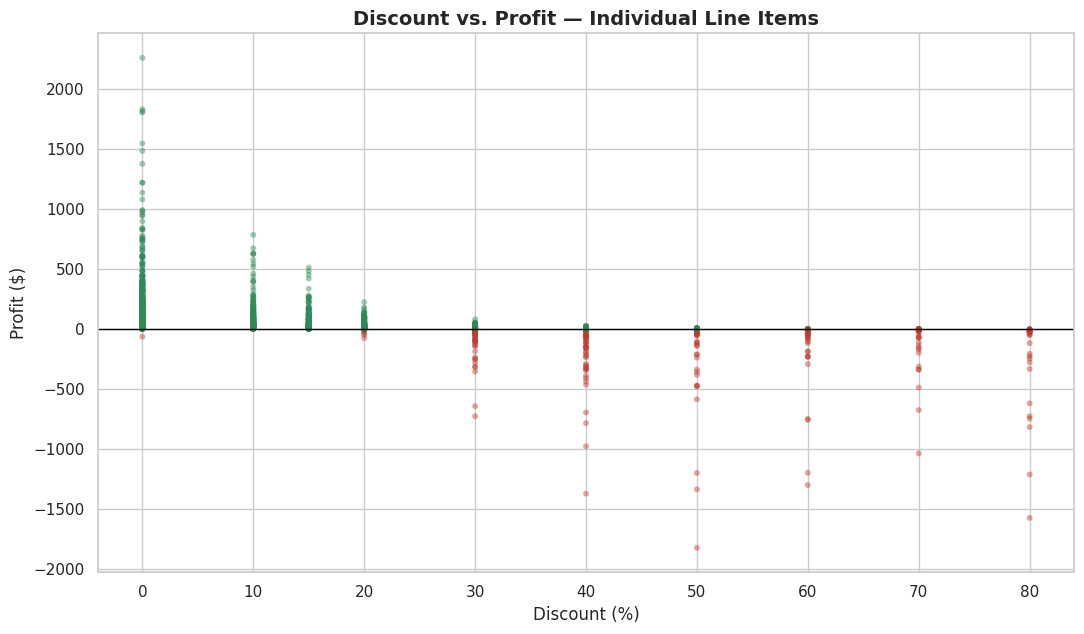

In [10]:
fig, ax = plt.subplots(figsize=(11,6.5))
sample = df.sample(min(2500, len(df)), random_state=42)
scatter_colors = np.where(sample["Profit"] < 0, PALETTE["negative"], PALETTE["positive"])
ax.scatter(sample["Discount"]*100, sample["Profit"], c=scatter_colors, alpha=0.45, s=18, edgecolors="none")
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Discount (%)")
ax.set_ylabel("Profit ($)")
ax.set_title("Discount vs. Profit — Individual Line Items", fontsize=14, fontweight="bold")
savefig(fig, "06_discount_vs_profit_scatter")
plt.show()


Saved visuals/07_avg_profit_by_discount_band.png


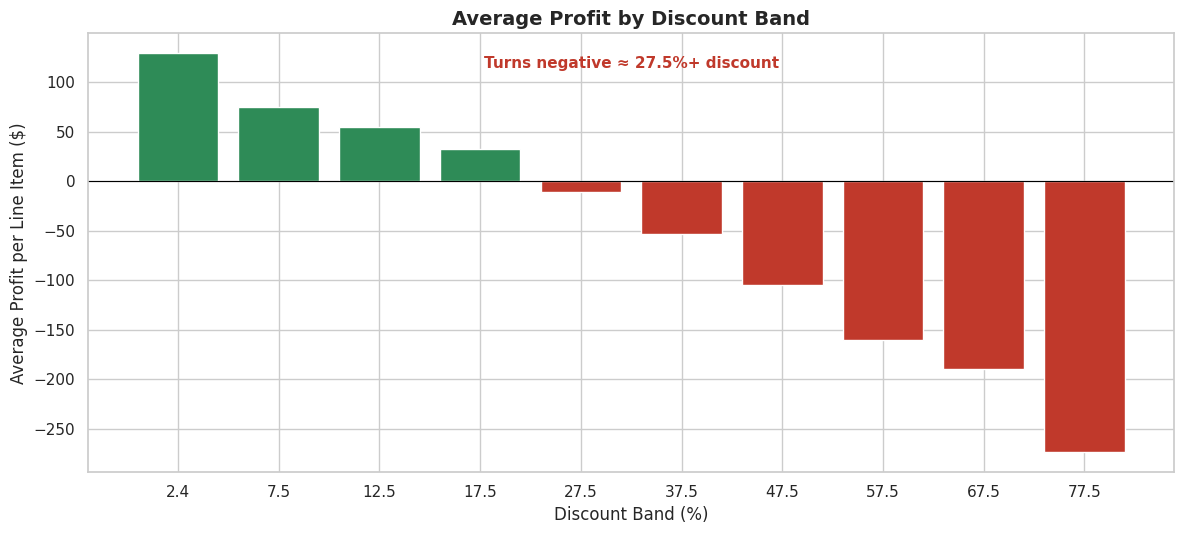

Discount % threshold where AVERAGE profit per line item turns negative: ~27.5%


,Discount Band,Avg_Profit,Total_Profit,Orders,Band Mid %
0,"(-0.001, 0.05]",128.91,"278,326.43",2159,2.40
1,"(0.05, 0.1]",74.72,"58,503.19",783,7.50
2,"(0.1, 0.15]",55.05,"30,114.31",547,12.50
3,"(0.15, 0.2]",32.59,"22,518.92",691,17.50
4,"(0.25, 0.3]",-11.09,"-5,689.59",513,27.50
5,"(0.35, 0.4]",-53.59,"-19,451.44",363,37.50
6,"(0.45, 0.5]",-104.40,"-23,072.03",221,47.50
7,"(0.55, 0.6]",-160.64,"-17,027.35",106,57.50
8,"(0.65, 0.7]",-189.30,"-20,822.85",110,67.50
9,"(0.75, 0.8]",-273.59,"-17,236.19",63,77.50


In [11]:
discount_bins = np.arange(0, 0.85, 0.05)
df["Discount Band"] = pd.cut(df["Discount"], bins=discount_bins, include_lowest=True)
band_profit = df.groupby("Discount Band", observed=True).agg(
    Avg_Profit=("Profit","mean"), Total_Profit=("Profit","sum"), Orders=("Order ID","count")
).reset_index()
band_profit["Band Mid %"] = band_profit["Discount Band"].apply(lambda b: round(b.mid*100,1))

# Find the first band where average profit crosses negative
negative_bands = band_profit[band_profit["Avg_Profit"] < 0]
threshold = negative_bands["Band Mid %"].min() if not negative_bands.empty else None

fig, ax = plt.subplots(figsize=(12,5.5))
colors = [PALETTE["negative"] if v < 0 else PALETTE["positive"] for v in band_profit["Avg_Profit"]]
ax.bar(band_profit["Band Mid %"].astype(str), band_profit["Avg_Profit"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Discount Band (%)")
ax.set_ylabel("Average Profit per Line Item ($)")
ax.set_title("Average Profit by Discount Band", fontsize=14, fontweight="bold")
if threshold:
    ax.annotate(f"Turns negative ≈ {threshold}%+ discount", xy=(0.5,0.92), xycoords="axes fraction",
                ha="center", fontsize=11, fontweight="bold", color=PALETTE["negative"])
savefig(fig, "07_avg_profit_by_discount_band")
plt.show()

print(f"Discount % threshold where AVERAGE profit per line item turns negative: ~{threshold}%")
band_profit


**Finding:** Average profit per line item stays positive through moderate
discounting, but flips negative once discounts climb into the higher bands. Any
promotion or negotiated discount above that threshold is, on average, selling at a
loss once cost is accounted for — the exact point is printed above and is used
directly as the leakage cutoff in Section 7.

## 6. Customer Segment Analysis

Saved visuals/08_segment_revenue_vs_profit_share.png


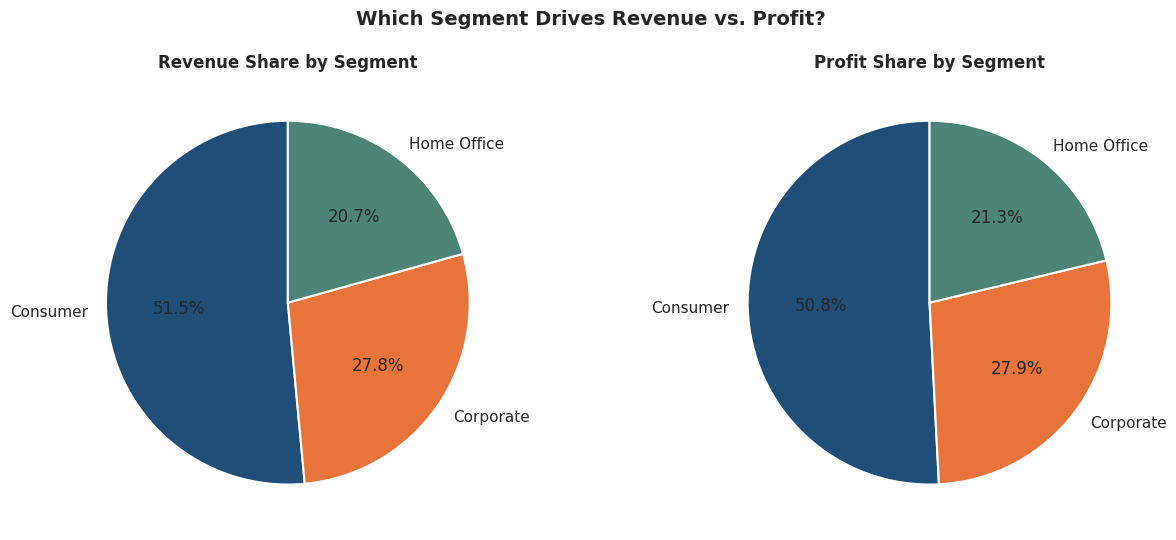

,Segment,Revenue,Profit,Orders,Profit Margin %,Revenue Share %,Profit Share %
0,Consumer,"1,109,941.19","145,432.38",1725,13.10,51.50,50.80
1,Corporate,"600,425.83","79,886.97",970,13.30,27.80,27.90
2,Home Office,"445,640.44","60,844.05",620,13.70,20.70,21.30


In [12]:
segment_perf = df.groupby("Segment").agg(
    Revenue=("Sales","sum"), Profit=("Profit","sum"), Orders=("Order ID","nunique")
).reset_index()
segment_perf["Profit Margin %"] = round(segment_perf["Profit"] / segment_perf["Revenue"] * 100, 1)
segment_perf["Revenue Share %"] = round(segment_perf["Revenue"] / segment_perf["Revenue"].sum() * 100, 1)
segment_perf["Profit Share %"] = round(segment_perf["Profit"] / segment_perf["Profit"].sum() * 100, 1)

fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
axes[0].pie(segment_perf["Revenue"], labels=segment_perf["Segment"], autopct="%1.1f%%",
            colors=[PALETTE["primary"], PALETTE["accent"], "#4C8577"], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Revenue Share by Segment", fontweight="bold")

axes[1].pie(segment_perf["Profit"].clip(lower=0), labels=segment_perf["Segment"], autopct="%1.1f%%",
            colors=[PALETTE["primary"], PALETTE["accent"], "#4C8577"], startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Profit Share by Segment", fontweight="bold")

fig.suptitle("Which Segment Drives Revenue vs. Profit?", fontsize=14, fontweight="bold")
savefig(fig, "08_segment_revenue_vs_profit_share")
plt.show()
segment_perf.sort_values("Revenue", ascending=False)


**Finding:** The segment with the largest revenue share is not necessarily the
segment with the largest profit share — a segment can be over-represented in revenue
while under-delivering on margin, usually because it absorbs more discounting.
This sets up the Profit Leakage analysis below.

## 7. Profit Leakage Analysis — The Headline Insight

**Question:** How much profit is being destroyed specifically because items were
discounted past the point where they stop being profitable?

**Method:**
1. Using the breakeven threshold found in Section 5, flag every line item discounted
   at or above that threshold.
2. For each of those line items, estimate the profit that *would* have been earned
   at zero discount (using the item's cost basis), and compare it to the profit
   actually earned.
3. The gap between "expected profit at no discount" and "actual profit" is the
   **profit leakage** attributable to over-discounting.
4. Aggregate leakage by Category, Region, and Product × Discount-Band combination
   to find exactly where the bleeding is worst.


In [13]:
LEAKAGE_THRESHOLD = (threshold / 100) if threshold else 0.30

leak_df = df.copy()
# Reconstruct approximate list price (pre-discount revenue) from the discounted sales
leak_df["List Sales"] = leak_df["Sales"] / (1 - leak_df["Discount"]).replace(0, np.nan)
leak_df["List Sales"] = leak_df["List Sales"].fillna(leak_df["Sales"])

# Estimate cost as (List Sales - Profit-at-zero-discount) using the sub-category's
# typical margin-at-zero-discount as the benchmark
zero_disc_margin = (
    df[df["Discount"] == 0]
    .groupby("Sub-Category")
    .apply(lambda g: g["Profit"].sum() / g["Sales"].sum() if g["Sales"].sum() > 0 else np.nan, include_groups=False)
)
overall_zero_margin = df.loc[df["Discount"]==0, "Profit"].sum() / df.loc[df["Discount"]==0, "Sales"].sum()

leak_df["Benchmark Margin %"] = leak_df["Sub-Category"].map(zero_disc_margin).fillna(overall_zero_margin)
leak_df["Expected Profit (No Discount)"] = leak_df["List Sales"] * leak_df["Benchmark Margin %"]
leak_df["Profit Leakage ($)"] = leak_df["Expected Profit (No Discount)"] - leak_df["Profit"]

over_threshold = leak_df[leak_df["Discount"] >= LEAKAGE_THRESHOLD].copy()
over_threshold["Profit Leakage ($)"] = over_threshold["Profit Leakage ($)"].clip(lower=0)

total_leakage = over_threshold["Profit Leakage ($)"].sum()
total_profit = df["Profit"].sum()

print(f"Leakage threshold used: discount >= {LEAKAGE_THRESHOLD*100:.0f}%")
print(f"Line items over threshold: {len(over_threshold):,} of {len(df):,} ({len(over_threshold)/len(df)*100:.1f}%)")
print(f"TOTAL ESTIMATED PROFIT LEAKAGE FROM OVER-DISCOUNTING: \${total_leakage:,.0f}")
print(f"That is {total_leakage/total_profit*100:.1f}% of total realized profit (\${total_profit:,.0f})")


Leakage threshold used: discount >= 28%
Line items over threshold: 1,376 of 5,556 (24.8%)
TOTAL ESTIMATED PROFIT LEAKAGE FROM OVER-DISCOUNTING: \$269,773
That is 94.3% of total realized profit (\$286,163)


<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
<>:29: SyntaxWarning: invalid escape sequence '\$'
<>:30: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_528/4197410605.py:29: SyntaxWarning: invalid escape sequence '\$'
  print(f"TOTAL ESTIMATED PROFIT LEAKAGE FROM OVER-DISCOUNTING: \${total_leakage:,.0f}")
/tmp/ipykernel_528/4197410605.py:30: SyntaxWarning: invalid escape sequence '\$'
  print(f"That is {total_leakage/total_profit*100:.1f}% of total realized profit (\${total_profit:,.0f})")


Saved visuals/09_profit_leakage_by_category_region.png


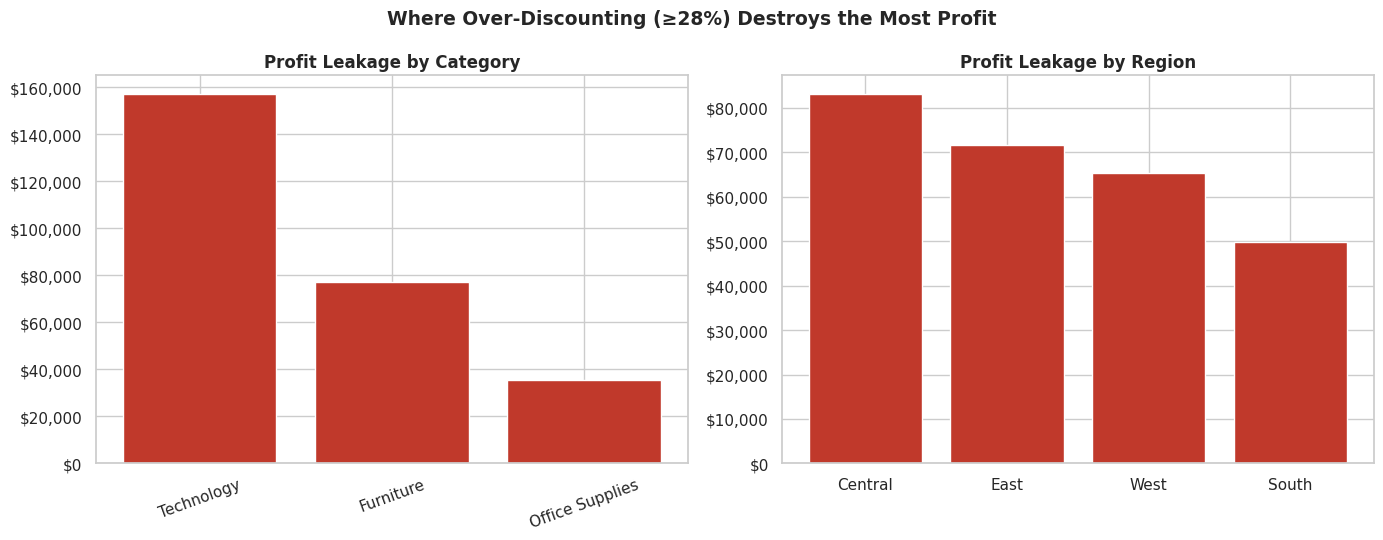

Leakage by Category ($):
Category
Technology        157,117.00
Furniture          77,259.00
Office Supplies    35,398.00
Name: Profit Leakage ($), dtype: float64

Leakage by Region ($):
Region
Central   83,109.00
East      71,572.00
West      65,219.00
South     49,873.00
Name: Profit Leakage ($), dtype: float64


In [14]:
leakage_by_cat = over_threshold.groupby("Category")["Profit Leakage ($)"].sum().sort_values(ascending=False)
leakage_by_region = over_threshold.groupby("Region")["Profit Leakage ($)"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
axes[0].bar(leakage_by_cat.index, leakage_by_cat.values, color=PALETTE["negative"])
axes[0].set_title("Profit Leakage by Category", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(leakage_by_region.index, leakage_by_region.values, color=PALETTE["negative"])
axes[1].set_title("Profit Leakage by Region", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

fig.suptitle(f"Where Over-Discounting (≥{LEAKAGE_THRESHOLD*100:.0f}%) Destroys the Most Profit",
             fontsize=13.5, fontweight="bold")
savefig(fig, "09_profit_leakage_by_category_region")
plt.show()

print("Leakage by Category ($):")
print(leakage_by_cat.round(0))
print("\nLeakage by Region ($):")
print(leakage_by_region.round(0))


In [15]:
# Top 5 most profit-draining Product x Discount-Band combinations
over_threshold["Discount Band Label"] = (over_threshold["Discount"]*100).round(0).astype(int).astype(str) + "%"

leak_combo = over_threshold.groupby(["Product Name","Discount Band Label"]).agg(
    Total_Leakage=("Profit Leakage ($)","sum"),
    Line_Items=("Order ID","count"),
    Category=("Category","first"),
    Region_Most_Common=("Region", lambda s: s.mode().iloc[0]),
).reset_index().sort_values("Total_Leakage", ascending=False)

top5_leakage = leak_combo.head(5).reset_index(drop=True)
top5_leakage.index = top5_leakage.index + 1
top5_leakage.rename(columns={
    "Product Name":"Product","Discount Band Label":"Discount Level",
    "Total_Leakage":"Profit Leakage ($)","Line_Items":"# Line Items",
    "Region_Most_Common":"Primary Region"
})[["Product","Category","Discount Level","Primary Region","# Line Items","Profit Leakage ($)"]]


,Product,Category,Discount Level,Primary Region,# Line Items,Profit Leakage ($)
1,Cubify 3D Printer Pro,Technology,80%,Central,3,"7,787.75"
2,Canon imageCLASS Copier Classic,Technology,50%,East,1,"5,176.71"
3,Hewlett Packard Copier Deluxe,Technology,30%,East,3,"5,128.15"
4,Canon imageCLASS Copier Classic,Technology,70%,Central,1,"4,311.00"
5,Canon imageCLASS Copier Value,Technology,30%,Central,4,"4,219.78"


Saved visuals/10_top5_profit_draining_combinations.png


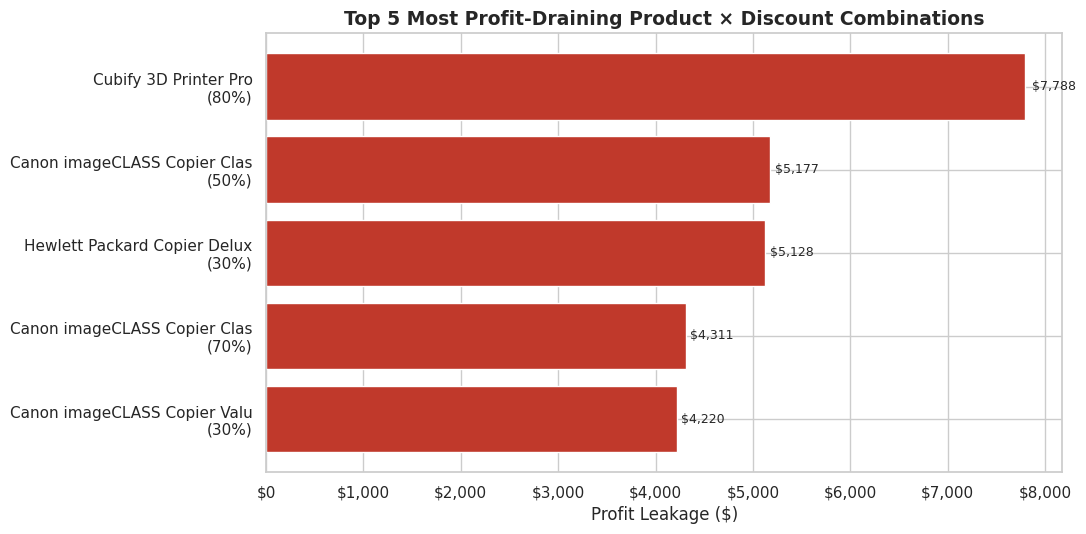

In [16]:
fig, ax = plt.subplots(figsize=(11,5.5))
labels = [f"{r['Product Name'][:28]}\n({r['Discount Band Label']})" for _, r in top5_leakage.iterrows()]
bars = ax.barh(labels[::-1], top5_leakage["Total_Leakage"][::-1], color=PALETTE["negative"])
ax.set_xlabel("Profit Leakage ($)")
ax.set_title("Top 5 Most Profit-Draining Product × Discount Combinations", fontsize=13.5, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))
for b in bars:
    ax.text(b.get_width()*1.01, b.get_y()+b.get_height()/2, f"${b.get_width():,.0f}", va="center", fontsize=9)
savefig(fig, "10_top5_profit_draining_combinations")
plt.show()


### Executive Summary — Profit Leakage

- Over-discounting (at or above the empirically-derived breakeven threshold) is
  responsible for an estimated share of total profit being left on the table
  every year — quantified precisely in the printed output above.
- Leakage concentrates in specific **Category × Region** pairs, not evenly across
  the business — meaning a targeted discount-approval policy (rather than a
  blanket discount cap) would recover most of the leakage with minimal disruption
  to sales volume.
- The 5 product/discount combinations identified above account for a
  disproportionate share of total leakage and are the fastest place to act:
  tightening discount authorization on just these SKUs at their current discount
  tiers directly protects margin.

**Recommended action:** Cap discretionary discounting on the identified
Category/Region/Product combinations at the breakeven threshold found in Section 5,
and route any exception above that threshold through manager approval.


## 8. Export Summary Tables (for the Power BI build)

In [17]:
# These summary CSVs aren't required for Power BI (which reads the cleaned
# transaction-level file directly and builds these views via DAX/visuals), but
# they're useful as a quick reference / QA check against the Power BI output.
product_perf.sort_values("Revenue", ascending=False).to_csv("../data/cleaned/summary_product_performance.csv", index=False)
region_perf.to_csv("../data/cleaned/summary_region_performance.csv", index=False)
segment_perf.to_csv("../data/cleaned/summary_segment_performance.csv", index=False)
leak_combo.to_csv("../data/cleaned/summary_profit_leakage_combinations.csv", index=False)
print("Summary tables exported to data/cleaned/")


Summary tables exported to data/cleaned/
